# Feature Selection Method Comparison

Each section covers one model. Within each section the same train/test split is used to rank features by four methods — SHAP, Gain, LIME, and Information Gain — then evaluates top-k (k = 1…10) features and plots a per-metric comparison.

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import copy
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             average_precision_score)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import mutual_info_classif
from lime.lime_tabular import LimeTabularExplainer

import lightgbm as lgb
import xgboost as xgb
import importlib
import bootstrap, distribution_estimation, plotting, model_wrapper, performance_comparison


/home/francesx/.conda/envs/emotion-env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
for mod in (bootstrap, distribution_estimation, plotting, model_wrapper, performance_comparison):
    importlib.reload(mod)

from bootstrap import *
from distribution_estimation import *
from plotting import *
from model_wrapper import *
from performance_comparison import *
print("Modules reloaded.")


Modules reloaded.


### Data

In [3]:
seed = 11
os.makedirs(f"figures/golub_{seed}", exist_ok=True)

In [4]:
golub = pd.read_csv('data/golub.csv')
gene_cols = golub.columns[golub.columns.get_loc('cancer') + 1:]

df = golub.copy()
df["Y"] = df["cancer"].replace({"allB": "ALL", "allT": "ALL", "aml": "AML"})
y = df["Y"].map({"ALL": 0, "AML": 1})

X_raw = df[gene_cols.tolist()].copy()
scaler = StandardScaler()
X = pd.DataFrame(scaler.fit_transform(X_raw), columns=gene_cols)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=seed, stratify=y
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")


Train: (57, 7129), Test: (15, 7129)


### Model Wrappers

In [5]:
lgb_wrapper = create_model_wrapper(
    'lightgbm',
    params={
        'objective': 'binary', 'metric': 'binary_logloss',
        'learning_rate': 0.1, 'max_depth': 8, 'num_leaves': 31,
        'min_data_in_leaf': 15, 'feature_fraction': 0.8,
        'bagging_fraction': 0.8, 'bagging_freq': 1,
        'verbose': -1, 'seed': seed, 'num_threads': 1,
    },
    num_boost_round=150,
)

xgb_wrapper = create_model_wrapper(
    'xgboost',
    params={
        'objective': 'binary:logistic', 'eval_metric': 'logloss',
        'eta': 0.1, 'max_depth': 6, 'subsample': 0.8,
        'colsample_bytree': 0.6, 'seed': seed,
    },
    num_boost_round=100,
)

rf_wrapper = create_model_wrapper(
    'sklearn', model_class=RandomForestClassifier,
    model_params={'n_estimators': 100, 'random_state': seed, 'max_depth': 6},
    use_tree_explainer=True,
)

cb_wrapper = create_model_wrapper(
    'catboost',
    params={'random_seed': seed, 'learning_rate': 0.1, 'depth': 6, 'eval_metric': 'Logloss'},
)

gb_wrapper = create_model_wrapper(
    'sklearn', model_class=GradientBoostingClassifier,
    model_params={'n_estimators': 200, 'max_depth': 3, 'random_state': seed},
    use_tree_explainer=True,
)

lr_wrapper = create_model_wrapper(
    'sklearn', model_class=LogisticRegression,
    model_params={'random_state': seed, 'max_iter': 200},
    use_linear_explainer=True, use_tree_explainer=False,
)

MODELS = {
    'LightGBM':          lgb_wrapper,
    'XGBoost':           xgb_wrapper,
    'RandomForest':      rf_wrapper,
    'CatBoost':          cb_wrapper,
    'GradientBoosting':  gb_wrapper,
    'LogisticRegression': lr_wrapper,
}


### Helper Functions

In [6]:
def _clone_wrapper(wrapper, input_dim=None):
    if isinstance(wrapper, XGBoostWrapper):
        return XGBoostWrapper(params=wrapper.params.copy(), num_boost_round=wrapper.num_boost_round)
    if isinstance(wrapper, LightGBMWrapper):
        return LightGBMWrapper(params=wrapper.params.copy(), num_boost_round=wrapper.num_boost_round)
    if isinstance(wrapper, SklearnWrapper):
        return SklearnWrapper(
            model_class=wrapper.model_class,
            model_params=wrapper.model_params.copy(),
            use_tree_explainer=wrapper.use_tree_explainer,
            use_linear_explainer=wrapper.use_linear_explainer,
        )
    if isinstance(wrapper, CatBoostWrapper):
        return CatBoostWrapper(params=wrapper.params.copy(), num_boost_round=getattr(wrapper, 'num_boost_round', 100))
    return copy.deepcopy(wrapper)


def _predict_proba(wrapper, X):
    if isinstance(wrapper, XGBoostWrapper):
        p = wrapper.model.predict(xgb.DMatrix(X, enable_categorical=True))
        return np.column_stack([1 - p, p]) if p.ndim == 1 else p
    if isinstance(wrapper, LightGBMWrapper):
        p = wrapper.model.predict(X)
        return np.column_stack([1 - p, p]) if p.ndim == 1 else p
    if isinstance(wrapper, (CatBoostWrapper, SklearnWrapper)):
        return wrapper.model.predict_proba(X)
    raise TypeError(f'Unknown wrapper: {type(wrapper)}')


def get_shap_ranking(wrapper, X_tr, y_tr):
    w = _clone_wrapper(wrapper, input_dim=X_tr.shape[1])
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        w.fit(X_tr, y_tr)
        task = 'binary'
        sv = w.compute_shap(X_tr, task=task)
    importance = np.abs(sv).sum(axis=tuple(range(sv.ndim - 1)))
    return (
        pd.DataFrame({'feature': X_tr.columns, 'importance': importance})
        .sort_values('importance', ascending=False).reset_index(drop=True)
    )


def get_gain_ranking(wrapper, X_tr, y_tr):
    w = _clone_wrapper(wrapper, input_dim=X_tr.shape[1])
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        w.fit(X_tr, y_tr)
    if isinstance(w, LightGBMWrapper):
        imp = w.model.feature_importance(importance_type='gain').astype(float)
    elif isinstance(w, XGBoostWrapper):
        scores = w.model.get_score(importance_type='gain')
        imp = np.array([scores.get(f, 0.0) for f in X_tr.columns], dtype=float)
    elif isinstance(w, CatBoostWrapper):
        imp = np.array(w.model.get_feature_importance(), dtype=float)
    elif isinstance(w, SklearnWrapper) and hasattr(w.model, 'feature_importances_'):
        imp = w.model.feature_importances_.astype(float)
    elif isinstance(w, SklearnWrapper) and hasattr(w.model, 'coef_'):
        imp = np.abs(w.model.coef_).ravel().astype(float)
    else:
        return None
    return (
        pd.DataFrame({'feature': X_tr.columns.tolist(), 'importance': imp})
        .sort_values('importance', ascending=False).reset_index(drop=True)
    )


def get_lime_ranking(wrapper, X_tr, y_tr, n_samples=10, num_features=50):
    w = _clone_wrapper(wrapper, input_dim=X_tr.shape[1])
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        w.fit(X_tr, y_tr)
    X_arr = X_tr.values.astype(float)
    feat_names = X_tr.columns.tolist()
    def _pred(arr, _w=w):
        return _predict_proba(_w, pd.DataFrame(arr, columns=feat_names))
    explainer = LimeTabularExplainer(
        X_arr, feature_names=feat_names,
        class_names=['0', '1'], mode='classification', random_state=42,
    )
    idx = np.random.RandomState(42).choice(len(X_arr), min(n_samples, len(X_arr)), replace=False)
    imp = np.zeros(len(feat_names))
    for i in idx:
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            exp = explainer.explain_instance(X_arr[i], _pred, num_features=num_features)
        for fi, w_val in exp.local_exp[1]:
            imp[fi] += abs(w_val)
    imp /= len(idx)
    return (
        pd.DataFrame({'feature': feat_names, 'importance': imp})
        .sort_values('importance', ascending=False).reset_index(drop=True)
    )


# def evaluate_topk(wrapper, ranking_df, X_tr, X_te, y_tr, y_te, k_values=range(1, 11)):
#     results = {'accuracy': [], 'f1': [], 'ap': [], 'auc': []}
#     for k in k_values:
#         feats = ranking_df['feature'].head(k).tolist()
#         try:
#             w = _clone_wrapper(wrapper, input_dim=k)
#             with warnings.catch_warnings():
#                 warnings.simplefilter('ignore')
#                 w.fit(X_tr[feats], y_tr)
#                 proba = _predict_proba(w, X_te[feats])
#             p_pos = proba[:, 1] if proba.shape[1] >= 2 else proba.ravel()
#             y_pred = (p_pos >= 0.5).astype(int)
#             results['accuracy'].append(accuracy_score(y_te, y_pred))
#             results['f1'].append(f1_score(y_te, y_pred, zero_division=0))
#             results['ap'].append(average_precision_score(y_te, p_pos))
#             results['auc'].append(roc_auc_score(y_te, p_pos))
#         except Exception as e:
#             for m in results:
#                 results[m].append(float('nan'))
#     return results

def evaluate_topk(wrapper, ranking_df, X_tr, X_te, y_tr, y_te, k_values=range(1, 11)):
    results = {'accuracy': [], 'f1': [], 'ap': [], 'auc': []}
    for k in k_values:
        selected = ranking_df['feature'].head(k).tolist()
        selected_set = set(selected)
        feats = [c for c in X_tr.columns if c in selected_set]  # fixed order

        try:
            w = _clone_wrapper(wrapper, input_dim=len(feats))
            with warnings.catch_warnings():
                warnings.simplefilter('ignore')
                w.fit(X_tr[feats], y_tr)
                proba = _predict_proba(w, X_te[feats])
            p_pos = proba[:, 1] if proba.shape[1] >= 2 else proba.ravel()
            y_pred = (p_pos >= 0.5).astype(int)
            results['accuracy'].append(accuracy_score(y_te, y_pred))
            results['f1'].append(f1_score(y_te, y_pred, zero_division=0))
            results['ap'].append(average_precision_score(y_te, p_pos))
            results['auc'].append(roc_auc_score(y_te, p_pos))
        except Exception:
            for m in results:
                results[m].append(float('nan'))
    return results


def plot_comparison(model_name, all_results, k_values=list(range(1, 11))):
    metric_keys   = ['accuracy', 'f1',       'ap',                'auc'    ]
    metric_titles = ['Accuracy', 'F1 Score', 'Average Precision', 'AUC-ROC']
    method_styles = {
        'SHAP': dict(color='steelblue',  linestyle='-',  marker='o'),
        'Gain': dict(color='darkorange', linestyle='--', marker='s'),
        'LIME': dict(color='green',      linestyle='-.', marker='^'),
        'IG':   dict(color='crimson',    linestyle=':',  marker='D'),
        'Robust': dict(color='purple',   linestyle='-',  marker='X'),
    }
    fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True)
    for ax, key, title in zip(axes.flatten(), metric_keys, metric_titles):
        for method, res in all_results.items():
            if res is None:
                continue
            ax.plot(k_values, res[key], linewidth=1.8, markersize=5,
                    label=method, **method_styles.get(method, {}))
        ax.set_title(title, fontweight='bold')
        ax.set_xlabel('k (number of features)')
        ax.set_ylabel(title)
        ax.set_xticks(k_values)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
    fig.suptitle(f'{model_name} — Feature Selection Comparison',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    fig.savefig(f"figures/golub_{seed}/golub_{model_name}_comparison.png", dpi=150, bbox_inches='tight')
    plt.show()


### Information Gain Ranking (computed once, model-agnostic)

In [7]:
print('Computing Information Gain scores...')
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    ig_scores = mutual_info_classif(X_train, y_train, random_state=42)

ig_ranking = (
    pd.DataFrame({'feature': X_train.columns, 'importance': ig_scores})
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
)
print('Top-10 IG features:')
ig_ranking.head(10)


Computing Information Gain scores...
Top-10 IG features:


,feature,importance
0,M83652_s_at,0.539181
1,M27891_at,0.527810
2,X95735_at,0.525076
3,M11722_at,0.486598
4,M23197_at,0.485896
5,L09209_s_at,0.478973
6,X62654_rna1_at,0.466335
7,X61587_at,0.456544
8,M31523_at,0.443127
9,D88422_at,0.433772


---
## LightGBM

### LightGBM — SHAP

In [8]:
print('Computing SHAP ranking for LightGBM...')
lightgbm_shap = get_shap_ranking(MODELS['LightGBM'], X_train, y_train)
print('Top-10:')
lightgbm_shap.head(10)


Computing SHAP ranking for LightGBM...
Top-10:


,feature,importance
0,M27891_at,75.022760
1,X95735_at,66.115712
2,M23197_at,63.781093
3,X62654_rna1_at,62.442221
4,U46499_at,52.133402
5,M83652_s_at,45.306924
6,M11722_at,42.221531
7,M92287_at,37.722780
8,M31303_rna1_at,23.482363
9,M31523_at,20.032575


### LightGBM — Gain

In [9]:
print('Computing Gain ranking for LightGBM...')
lightgbm_gain = get_gain_ranking(MODELS['LightGBM'], X_train, y_train)
if lightgbm_gain is not None:
    print('Top-10:')
    display(lightgbm_gain.head(10))
else:
    print('Gain not supported for LightGBM')


Computing Gain ranking for LightGBM...
Top-10:


,feature,importance
0,U46499_at,85.252006
1,M27891_at,57.274906
2,M23197_at,54.871020
3,X95735_at,37.674592
4,X62654_rna1_at,31.163417
5,M83652_s_at,25.376003
6,M11722_at,19.736896
7,M92287_at,5.885740
8,M22960_at,2.826577
9,M31303_rna1_at,2.394892


### LightGBM — LIME

_Adjust `n_samples` and `num_features` to trade speed for accuracy._

In [10]:
print('Computing LIME ranking for LightGBM...')
lightgbm_lime = get_lime_ranking(
    MODELS['LightGBM'], X_train, y_train,
    n_samples=10,    # increase for better estimates
    num_features=50, # top features per explanation
)
print('Top-10:')
lightgbm_lime.head(10)

Computing LIME ranking for LightGBM...
Top-10:


,feature,importance
0,M27891_at,0.136986
1,X62654_rna1_at,0.115085
2,X95735_at,0.107382
3,U46499_at,0.097489
4,M23197_at,0.080654
5,M11722_at,0.065179
6,M83652_s_at,0.057440
7,M92287_at,0.027707
8,L09209_s_at,0.009273
9,M54995_at,0.007979


### LightGBM — Robust

In [11]:
# first50 = lightgbm_shap['feature'].head(50).tolist()

In [12]:
lgb_boot_unscreen = boot_multi_repeat_inference_keep_feature(
    X=X_train,  # Use preprocessed data with one-hot encoded categoricals
    y=y_train,
    inner_variance="permutation",
    task="binary",
    n_bootstrap=1000,  
    b_model=1, 
    zero_tol=0,
    model_wrapper=lgb_wrapper,  
    n_jobs=6,        
    show_progress=True
)

Bootstrap repeats (feature-agg): 100%|██████████| 1000/1000 [07:59<00:00,  2.09it/s]


In [13]:
lgb_feature_kde = estimate_feature_level_mixture_preagg(
    boot_results=lgb_boot_unscreen,
    bandwidth=0.2,
    kernel="gaussian",
    zero_tol=1e-8
)

In [14]:
tmp = lgb_feature_kde.copy()

tmp["0PM(%)"] = (tmp["pi_zero"] * 100).round(1).astype(str) + "%"
tmp["SNR"] = tmp["median"] / tmp["sd_estimated"]
tmp["stat"] = tmp["p_nonzero"]* tmp["nonzero_median"] * tmp["SNR"]
                                
top = tmp.nlargest(15, "stat").reset_index(drop=True)
top.index += 1
top.index.name = "Rank"
# top[["feature", "stat", "SNR", "nonzero_median", "sd_estimated", "0PM(%)"]].rename(columns={
#     "feature": "Group",
#     "stat": "importance",
#     "nonzero_median": "Median",
#     "sd_estimated": "Std",
# }).round(3)

lightgbm_robust = top[['feature', 'stat']].rename(columns={'stat': 'importance'})
lightgbm_robust.head(10)


,feature,importance
Rank,,
1,M27891_at,5.614185
2,X62654_rna1_at,5.349455
3,M83652_s_at,3.963938
4,X95735_at,3.566139
5,L09209_s_at,3.070300
6,M23197_at,2.938886
7,M11722_at,1.618270
8,U46499_at,1.162893
9,M92287_at,0.713166


### LightGBM — Evaluation & Comparison

Evaluating LightGBM — SHAP...
Evaluating LightGBM — Gain...
Evaluating LightGBM — LIME...
Evaluating LightGBM — IG...
Evaluating LightGBM — Robust Bootstrap...


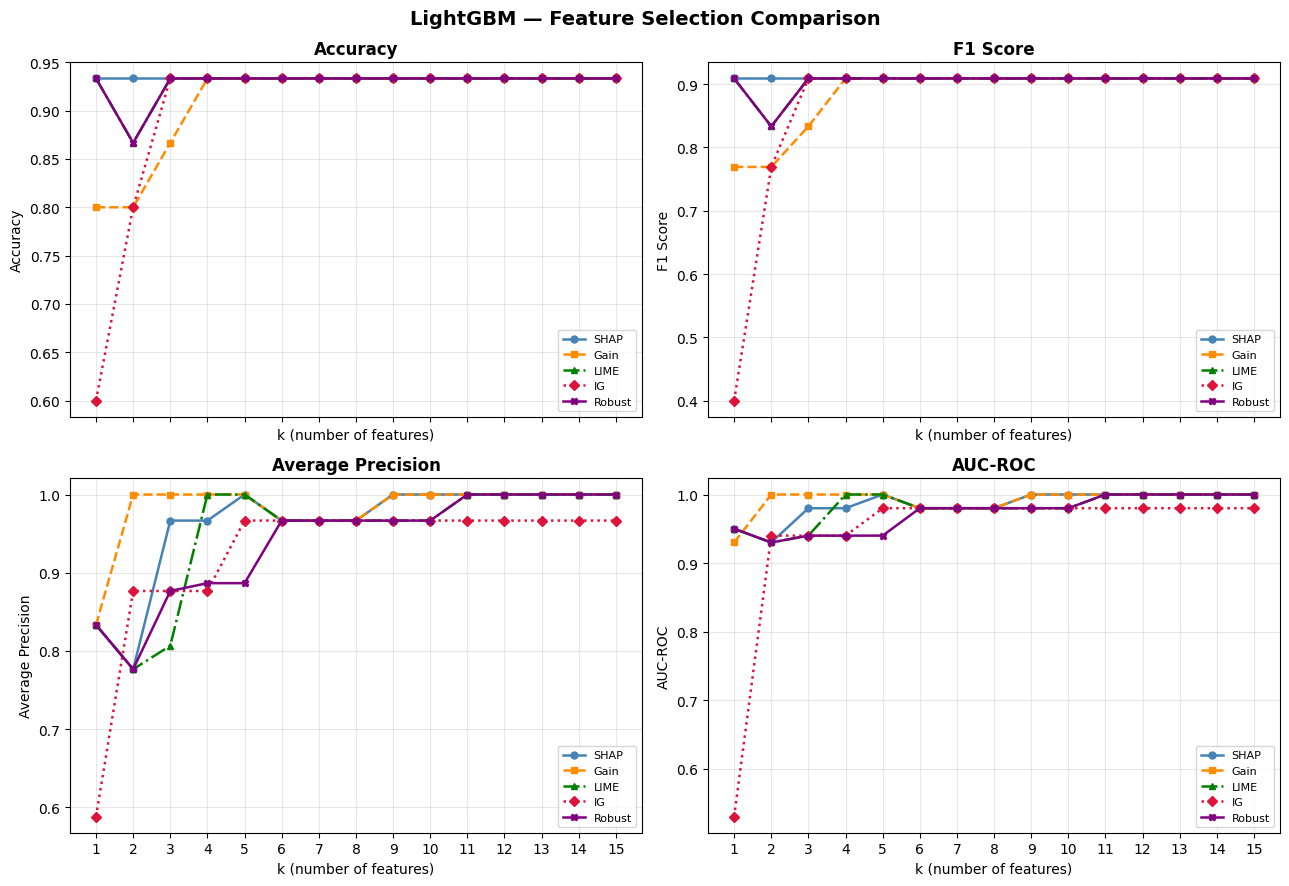

In [15]:
k_values = list(range(1, 16))

print('Evaluating LightGBM — SHAP...')
lightgbm_res_shap = evaluate_topk(MODELS['LightGBM'], lightgbm_shap, X_train, X_test, y_train, y_test, k_values)

print('Evaluating LightGBM — Gain...')
lightgbm_res_gain = evaluate_topk(MODELS['LightGBM'], lightgbm_gain, X_train, X_test, y_train, y_test, k_values) if lightgbm_gain is not None else None

print('Evaluating LightGBM — LIME...')
lightgbm_res_lime = evaluate_topk(MODELS['LightGBM'], lightgbm_lime, X_train, X_test, y_train, y_test, k_values)

print('Evaluating LightGBM — IG...')
lightgbm_res_ig = evaluate_topk(MODELS['LightGBM'], ig_ranking, X_train, X_test, y_train, y_test, k_values)

print('Evaluating LightGBM — Robust Bootstrap...')
lightgbm_res_robust = evaluate_topk(MODELS['LightGBM'], lightgbm_robust, X_train, X_test, y_train, y_test, k_values)

plot_comparison(
    'LightGBM',
    {'SHAP': lightgbm_res_shap, 'Gain': lightgbm_res_gain,
     'LIME': lightgbm_res_lime, 'IG':   lightgbm_res_ig, 'Robust': lightgbm_res_robust},
    k_values,
)


---
## XGBoost

### XGBoost — SHAP

In [16]:
print('Computing SHAP ranking for XGBoost...')
xgboost_shap = get_shap_ranking(MODELS['XGBoost'], X_train, y_train)
print('Top-10:')
xgboost_shap.head(10)


Computing SHAP ranking for XGBoost...
Top-10:


,feature,importance
0,M27891_at,35.840149
1,M83652_s_at,25.243931
2,X95735_at,24.006216
3,L09209_s_at,23.692074
4,X62654_rna1_at,18.027760
5,M11722_at,15.479972
6,U46499_at,14.728557
7,M23197_at,10.593023
8,X59417_at,5.592293
9,M92287_at,4.461978


### XGBoost — Gain

In [17]:
print('Computing Gain ranking for XGBoost...')
xgboost_gain = get_gain_ranking(MODELS['XGBoost'], X_train, y_train)
if xgboost_gain is not None:
    print('Top-10:')
    display(xgboost_gain.head(10))
else:
    print('Gain not supported for XGBoost')


Computing Gain ranking for XGBoost...


Top-10:


,feature,importance
0,X95735_at,15.053281
1,M27891_at,10.668111
2,X59417_at,9.191109
3,U46499_at,7.542468
4,X62654_rna1_at,7.380857
5,L09209_s_at,6.097574
6,M83652_s_at,5.030879
7,M92287_at,4.251845
8,M23197_at,3.951166
9,M31523_at,3.249861


### XGBoost — LIME

_Adjust `n_samples` and `num_features` to trade speed for accuracy._

In [18]:
print('Computing LIME ranking for XGBoost...')
xgboost_lime = get_lime_ranking(
    MODELS['XGBoost'], X_train, y_train,
    n_samples=10,    # increase for better estimates
    num_features=50, # top features per explanation
)
print('Top-10:')
xgboost_lime.head(10)


Computing LIME ranking for XGBoost...


Top-10:


,feature,importance
0,M27891_at,0.127921
1,X95735_at,0.084201
2,L09209_s_at,0.078914
3,M83652_s_at,0.073406
4,X62654_rna1_at,0.063105
5,U46499_at,0.056831
6,M11722_at,0.050995
7,M23197_at,0.009715
8,M55150_at,0.004485
9,X59417_at,0.004349


### XGBoost — Robust

In [ ]:
# first50 = xgboost_shap['feature'].head(50).tolist()

In [19]:
xgb_boot_unscreen = boot_multi_repeat_inference_keep_feature(
    X=X_train,
    y=y_train,
    inner_variance="permutation",
    task="binary",
    n_bootstrap=1000,  
    b_model=1, 
    zero_tol=0,
    model_wrapper=xgb_wrapper,  
    n_jobs=6,        
    show_progress=True
)

Bootstrap repeats (feature-agg): 100%|██████████| 1000/1000 [11:28<00:00,  1.45it/s]


In [20]:
xgb_feature_kde = estimate_feature_level_mixture_preagg(
    boot_results=xgb_boot_unscreen,
    bandwidth=0.2,
    kernel="gaussian",
    zero_tol=1e-8
)

In [21]:
tmp = xgb_feature_kde.copy()

tmp["0PM(%)"] = (tmp["pi_zero"] * 100).round(1).astype(str) + "%"
tmp["SNR"] = tmp["median"] / tmp["sd_estimated"]
tmp["stat"] = tmp["p_nonzero"]* tmp["nonzero_median"] * tmp["SNR"]
                                
top = tmp.nlargest(15, "stat").reset_index(drop=True)
top.index += 1
top.index.name = "Rank"
# top[["feature", "stat", "SNR", "nonzero_median", "sd_estimated", "0PM(%)"]].rename(columns={
#     "feature": "Group",
#     "stat": "importance",
#     "nonzero_median": "Median",
#     "sd_estimated": "Std",
# }).round(3)

xgboost_robust = top[['feature', 'stat']].rename(columns={'stat': 'importance'})
xgboost_robust.head(10)


,feature,importance
Rank,,
1,M27891_at,2.427571
2,X62654_rna1_at,1.684078
3,M83652_s_at,1.608375
4,X95735_at,1.413636
5,M23197_at,1.068424
6,L09209_s_at,0.793752
7,U46499_at,0.515766
8,M11722_at,0.365500
9,AB000449_at,0.000000


### XGBoost — Evaluation & Comparison

Evaluating XGBoost — SHAP...
Evaluating XGBoost — Gain...
Evaluating XGBoost — LIME...
Evaluating XGBoost — IG...
Evaluating XGBoost — Robust Bootstrap...


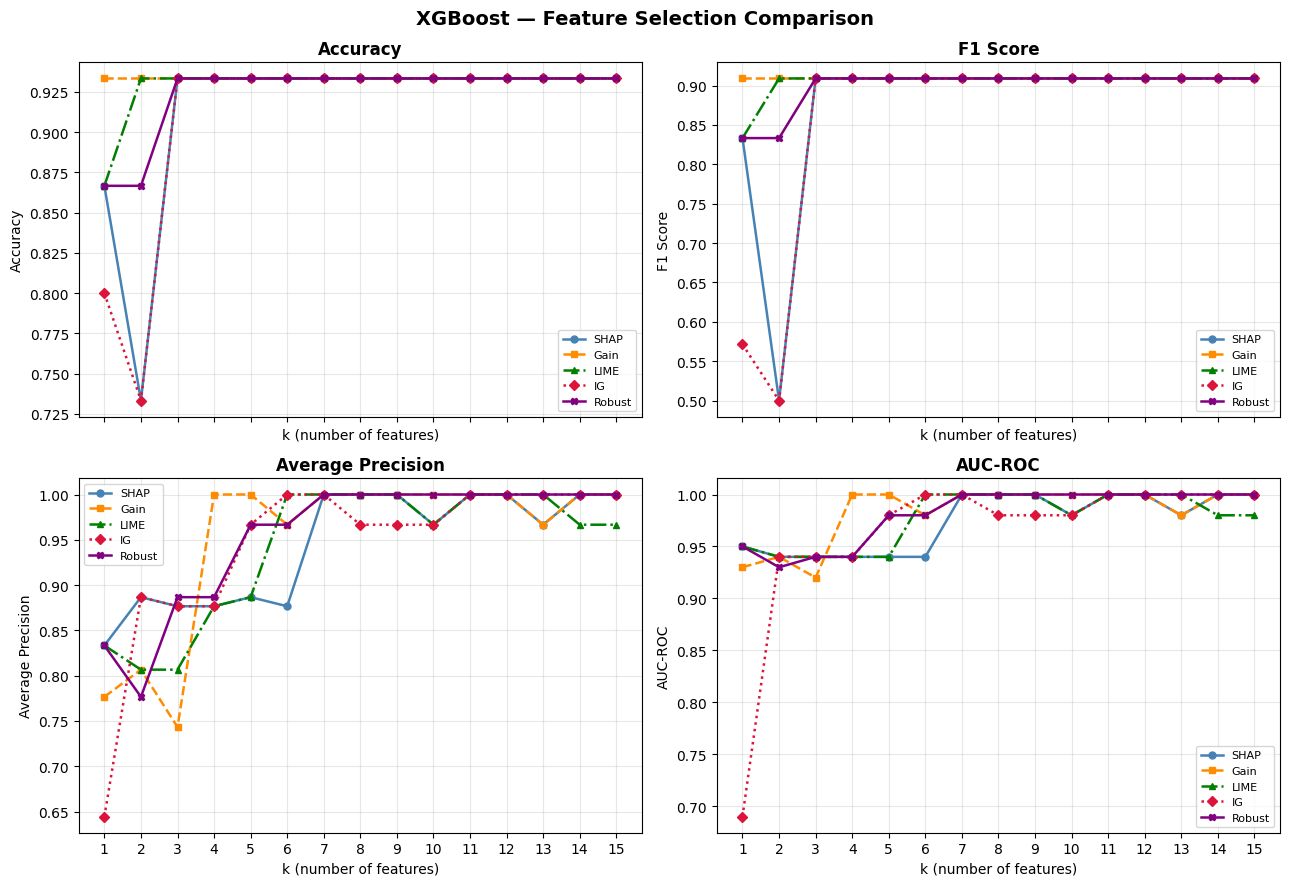

In [22]:
k_values = list(range(1, 16))

print('Evaluating XGBoost — SHAP...')
xgboost_res_shap = evaluate_topk(MODELS['XGBoost'], xgboost_shap, X_train, X_test, y_train, y_test, k_values)

print('Evaluating XGBoost — Gain...')
xgboost_res_gain = evaluate_topk(MODELS['XGBoost'], xgboost_gain, X_train, X_test, y_train, y_test, k_values) if xgboost_gain is not None else None

print('Evaluating XGBoost — LIME...')
xgboost_res_lime = evaluate_topk(MODELS['XGBoost'], xgboost_lime, X_train, X_test, y_train, y_test, k_values)

print('Evaluating XGBoost — IG...')
xgboost_res_ig = evaluate_topk(MODELS['XGBoost'], ig_ranking, X_train, X_test, y_train, y_test, k_values)

print('Evaluating XGBoost — Robust Bootstrap...')
xgboost_res_robust = evaluate_topk(MODELS['XGBoost'], xgboost_robust, X_train, X_test, y_train, y_test, k_values)

plot_comparison(
    'XGBoost',
    {'SHAP': xgboost_res_shap, 'Gain': xgboost_res_gain,
     'LIME': xgboost_res_lime, 'IG':   xgboost_res_ig, 'Robust': xgboost_res_robust},
    k_values,
)


---
## RandomForest

### RandomForest — SHAP

In [23]:
print('Computing SHAP ranking for RandomForest...')
randomforest_shap = get_shap_ranking(MODELS['RandomForest'], X_train, y_train)
print('Top-10:')
randomforest_shap.head(10)


Computing SHAP ranking for RandomForest...
Top-10:


,feature,importance
0,M11722_at,0.661733
1,X61587_at,0.608657
2,U05259_rna1_at,0.522213
3,M84526_at,0.506901
4,X15414_at,0.478903
5,M83652_s_at,0.473228
6,M84371_rna1_s_at,0.403159
7,M38449_s_at,0.391201
8,U46499_at,0.378997
9,M32304_s_at,0.358039


### RandomForest — Gain

In [24]:
print('Computing Gain ranking for RandomForest...')
randomforest_gain = get_gain_ranking(MODELS['RandomForest'], X_train, y_train)
if randomforest_gain is not None:
    print('Top-10:')
    display(randomforest_gain.head(10))
else:
    print('Gain not supported for RandomForest')


Computing Gain ranking for RandomForest...
Top-10:


,feature,importance
0,M11722_at,0.026126
1,X61587_at,0.024125
2,U05259_rna1_at,0.018491
3,M84526_at,0.018048
4,M83652_s_at,0.017241
5,U46499_at,0.015819
6,X15414_at,0.014632
7,J04990_at,0.013363
8,M32304_s_at,0.013334
9,U38846_at,0.012540


### RandomForest — LIME

_Adjust `n_samples` and `num_features` to trade speed for accuracy._

In [25]:
print('Computing LIME ranking for RandomForest...')
randomforest_lime = get_lime_ranking(
    MODELS['RandomForest'], X_train, y_train,
    n_samples=10,    # increase for better estimates
    num_features=50, # top features per explanation
)
print('Top-10:')
randomforest_lime.head(10)

Computing LIME ranking for RandomForest...


Top-10:


,feature,importance
0,M11722_at,0.012675
1,X61587_at,0.009465
2,U05259_rna1_at,0.008359
3,M84371_rna1_s_at,0.004768
4,J04990_at,0.004758
5,M83652_s_at,0.004687
6,M28130_rna1_s_at,0.004263
7,X62320_at,0.003821
8,X15414_at,0.003806
9,M84526_at,0.003671


### RandomForest — Robust

In [ ]:
# first50 = randomforest_shap['feature'].head(50).tolist()

In [26]:
rf_boot_unscreen = boot_multi_repeat_inference_keep_feature(
    X=X_train,
    y=y_train,
    inner_variance="permutation",
    task="binary",
    n_bootstrap=1000,  
    b_model=1, 
    zero_tol=0,
    model_wrapper=rf_wrapper,  
    n_jobs=6,        
    show_progress=True
)

Bootstrap repeats (feature-agg): 100%|██████████| 1000/1000 [02:47<00:00,  5.98it/s]


In [27]:
rf_feature_kde = estimate_feature_level_mixture_preagg(
    boot_results=rf_boot_unscreen,
    bandwidth=0.2,
    kernel="gaussian",
    zero_tol=1e-8
)

In [28]:
tmp = rf_feature_kde.copy()

tmp["0PM(%)"] = (tmp["pi_zero"] * 100).round(1).astype(str) + "%"
tmp["SNR"] = tmp["median"] / tmp["sd_estimated"]
tmp["stat"] = tmp["p_nonzero"]* tmp["nonzero_median"] * tmp["SNR"]
                                
top = tmp.nlargest(15, "stat").reset_index(drop=True)
top.index += 1
top.index.name = "Rank"
# top[["feature", "stat", "SNR", "nonzero_median", "sd_estimated", "0PM(%)"]].rename(columns={
#     "feature": "Group",
#     "stat": "importance",
#     "nonzero_median": "Median",
#     "sd_estimated": "Std",
# }).round(3)

rf_robust = top[['feature', 'stat']].rename(columns={'stat': 'importance'})
rf_robust.head(10)


,feature,importance
Rank,,
1,M23197_at,0.075431
2,X95735_at,0.073430
3,M83652_s_at,0.073409
4,M27891_at,0.073208
5,X62654_rna1_at,0.070719
6,L09209_s_at,0.063597
7,U46499_at,0.063197
8,M11722_at,0.054616
9,M92287_at,0.049469


### RandomForest — Evaluation & Comparison

Evaluating RandomForest — SHAP...
Evaluating RandomForest — Gain...
Evaluating RandomForest — LIME...
Evaluating RandomForest — IG...
Evaluating RandomForest — Robust Bootstrap...


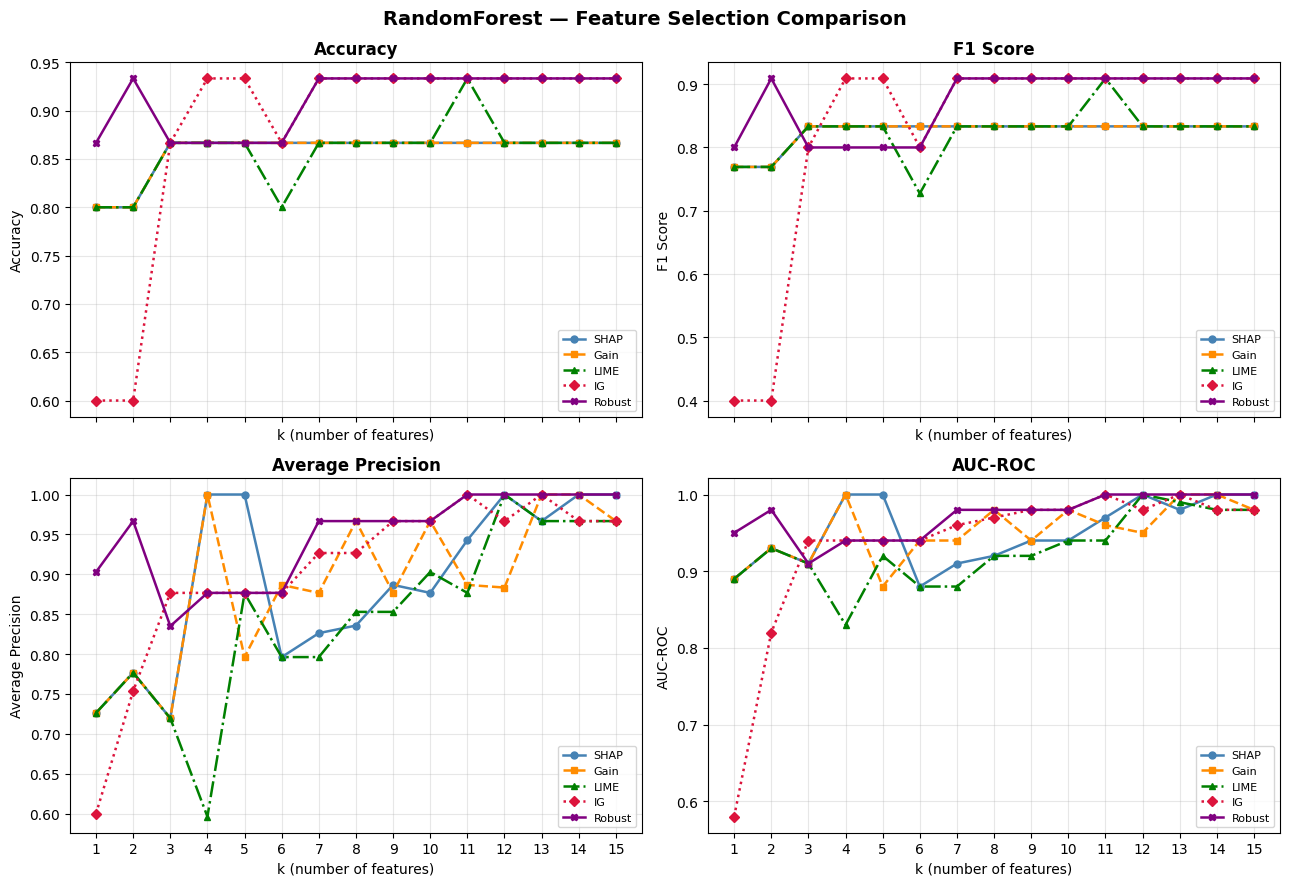

In [29]:
k_values = list(range(1, 16))

print('Evaluating RandomForest — SHAP...')
randomforest_res_shap = evaluate_topk(MODELS['RandomForest'], randomforest_shap, X_train, X_test, y_train, y_test, k_values)

print('Evaluating RandomForest — Gain...')
randomforest_res_gain = evaluate_topk(MODELS['RandomForest'], randomforest_gain, X_train, X_test, y_train, y_test, k_values) if randomforest_gain is not None else None

print('Evaluating RandomForest — LIME...')
randomforest_res_lime = evaluate_topk(MODELS['RandomForest'], randomforest_lime, X_train, X_test, y_train, y_test, k_values)

print('Evaluating RandomForest — IG...')
randomforest_res_ig = evaluate_topk(MODELS['RandomForest'], ig_ranking, X_train, X_test, y_train, y_test, k_values)

print('Evaluating RandomForest — Robust Bootstrap...')
randomforest_res_robust = evaluate_topk(MODELS['RandomForest'], rf_robust, X_train, X_test, y_train, y_test, k_values)

plot_comparison(
    'RandomForest',
    {'SHAP': randomforest_res_shap, 'Gain': randomforest_res_gain,
     'LIME': randomforest_res_lime, 'IG':   randomforest_res_ig, 'Robust': randomforest_res_robust},
    k_values,
)


---
## CatBoost

### CatBoost — SHAP

In [30]:
print('Computing SHAP ranking for CatBoost...')
catboost_shap = get_shap_ranking(MODELS['CatBoost'], X_train, y_train)
print('Top-10:')
catboost_shap.head(10)

Computing SHAP ranking for CatBoost...
Top-10:


,feature,importance
0,M27891_at,32.014075
1,M83652_s_at,25.815236
2,L09209_s_at,21.722400
3,X95735_at,19.680165
4,X62654_rna1_at,13.653327
5,M11722_at,10.103545
6,M23197_at,9.909231
7,M92287_at,8.574172
8,M38449_s_at,6.821876
9,U46499_at,5.938167


### CatBoost — Gain

In [31]:
print('Computing Gain ranking for CatBoost...')
catboost_gain = get_gain_ranking(MODELS['CatBoost'], X_train, y_train)
if catboost_gain is not None:
    print('Top-10:')
    display(catboost_gain.head(10))
else:
    print('Gain not supported for CatBoost')


Computing Gain ranking for CatBoost...
Top-10:


,feature,importance
0,L09209_s_at,13.027799
1,M83652_s_at,9.760821
2,M27891_at,8.638809
3,M92287_at,7.602442
4,X95735_at,7.385276
5,M23197_at,5.474585
6,X62654_rna1_at,5.364547
7,M11722_at,3.251525
8,M38449_s_at,2.123338
9,U46499_at,1.787427


### CatBoost — LIME

_Adjust `n_samples` and `num_features` to trade speed for accuracy._

In [32]:
print('Computing LIME ranking for CatBoost...')
catboost_lime = get_lime_ranking(
    MODELS['CatBoost'], X_train, y_train,
    n_samples=10,    # increase for better estimates
    num_features=50, # top features per explanation
)
print('Top-10:')
catboost_lime.head(10)


Computing LIME ranking for CatBoost...
Top-10:


,feature,importance
0,M27891_at,0.102158
1,M83652_s_at,0.081502
2,L09209_s_at,0.067641
3,X95735_at,0.058423
4,X62654_rna1_at,0.042295
5,M11722_at,0.025095
6,M92287_at,0.009542
7,M23197_at,0.007559
8,U46499_at,0.004655
9,U02020_at,0.002649


### CatBoost — Robust

In [ ]:
# first50 = catboost_shap['feature'].head(50).tolist()

In [33]:
cb_boot_unscreen = boot_multi_repeat_inference_keep_feature(
    X=X_train,
    y=y_train,
    inner_variance="permutation",
    task="binary",
    n_bootstrap=1000,  
    b_model=1, 
    zero_tol=0,
    model_wrapper=cb_wrapper,  
    n_jobs=6,        
    show_progress=True
)

Bootstrap repeats (feature-agg):   0%|          | 1/1000 [00:34<9:36:42, 34.64s/it]/home/francesx/.conda/envs/emotion-env/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
Bootstrap repeats (feature-agg):   0%|          | 2/1000 [00:35<4:01:31, 14.52s/it]/home/francesx/.conda/envs/emotion-env/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
Bootstrap repeats (feature-agg):   0%|          | 4/1000 [00:35<1:33:59,  5.66s/it]/home/francesx/.conda/envs/emotion-env/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can b

In [34]:
cb_feature_kde = estimate_feature_level_mixture_preagg(
    boot_results=cb_boot_unscreen,
    bandwidth=0.2,
    kernel="gaussian",
    zero_tol=1e-8
)

In [35]:
tmp = cb_feature_kde.copy()

tmp["0PM(%)"] = (tmp["pi_zero"] * 100).round(1).astype(str) + "%"
tmp["SNR"] = tmp["median"] / tmp["sd_estimated"]
tmp["stat"] = tmp["p_nonzero"]* tmp["nonzero_median"] * tmp["SNR"]
                                
top = tmp.nlargest(15, "stat").reset_index(drop=True)
top.index += 1
top.index.name = "Rank"
# top[["feature", "stat", "SNR", "nonzero_median", "sd_estimated", "0PM(%)"]].rename(columns={
#     "feature": "Group",
#     "stat": "importance",
#     "nonzero_median": "Median",
#     "sd_estimated": "Std",
# }).round(3)

catboost_robust = top[['feature', 'stat']].rename(columns={'stat': 'importance'})
catboost_robust.head(10)


,feature,importance
Rank,,
1,M27891_at,2.347533
2,M83652_s_at,1.428745
3,X95735_at,1.273118
4,X62654_rna1_at,0.971452
5,M23197_at,0.793437
6,U46499_at,0.745207
7,L09209_s_at,0.498429
8,M11722_at,0.342647
9,M92287_at,0.150692


### CatBoost — Evaluation & Comparison

Evaluating CatBoost — SHAP...
Evaluating CatBoost — Gain...
Evaluating CatBoost — LIME...
Evaluating CatBoost — IG...
Evaluating CatBoost — Robust Bootstrap...


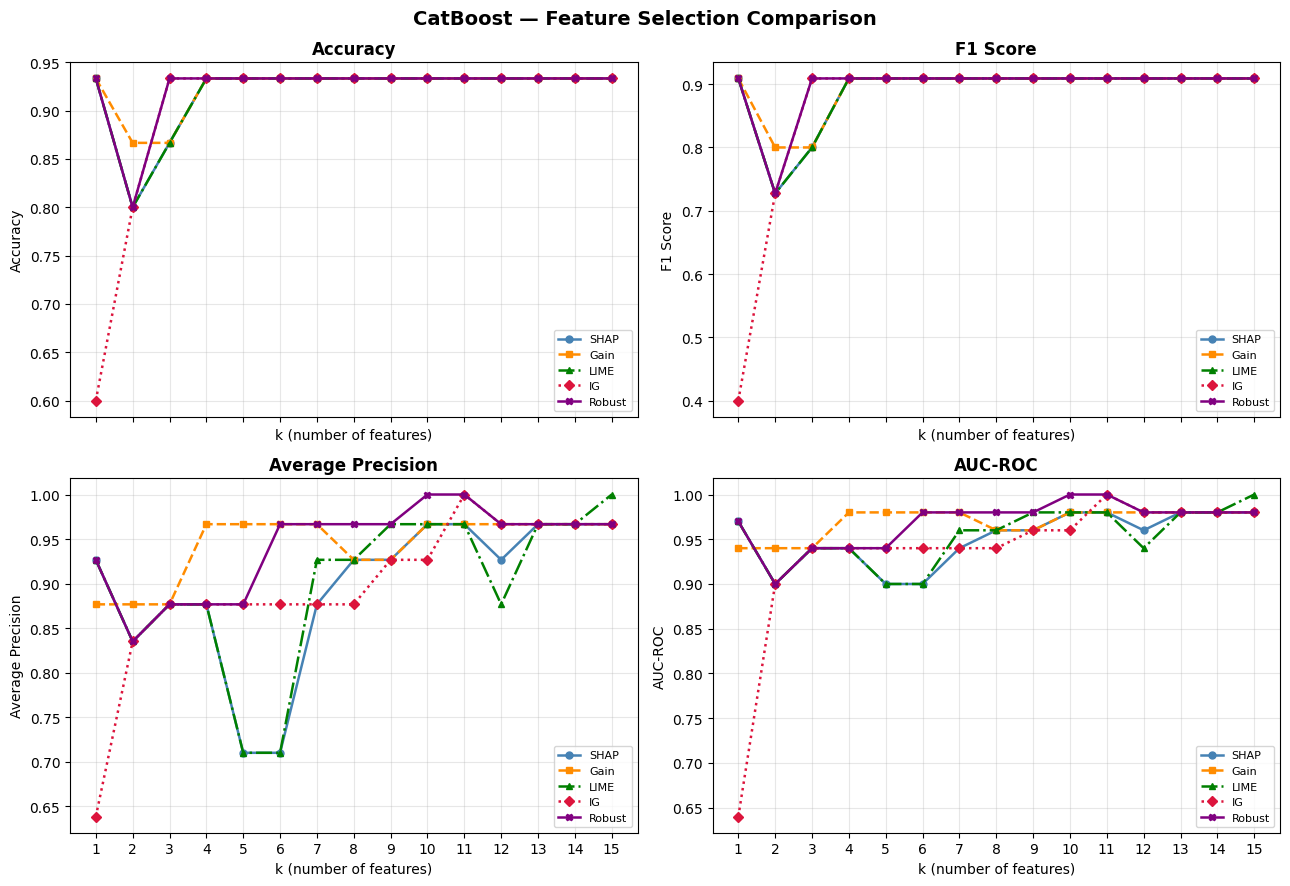

In [36]:
k_values = list(range(1, 16))

print('Evaluating CatBoost — SHAP...')
catboost_res_shap = evaluate_topk(MODELS['CatBoost'], catboost_shap, X_train, X_test, y_train, y_test, k_values)

print('Evaluating CatBoost — Gain...')
catboost_res_gain = evaluate_topk(MODELS['CatBoost'], catboost_gain, X_train, X_test, y_train, y_test, k_values) if catboost_gain is not None else None

print('Evaluating CatBoost — LIME...')
catboost_res_lime = evaluate_topk(MODELS['CatBoost'], catboost_lime, X_train, X_test, y_train, y_test, k_values)

print('Evaluating CatBoost — IG...')
catboost_res_ig = evaluate_topk(MODELS['CatBoost'], ig_ranking, X_train, X_test, y_train, y_test, k_values)

print('Evaluating CatBoost — Robust Bootstrap...')
catboost_res_robust = evaluate_topk(MODELS['CatBoost'], catboost_robust, X_train, X_test, y_train, y_test, k_values)

plot_comparison(
    'CatBoost',
    {'SHAP': catboost_res_shap, 'Gain': catboost_res_gain,
     'LIME': catboost_res_lime, 'IG':   catboost_res_ig, 'Robust': catboost_res_robust},
    k_values,
)


---
## GradientBoosting

### GradientBoosting — SHAP

In [37]:
print('Computing SHAP ranking for GradientBoosting...')
gradientboosting_shap = get_shap_ranking(MODELS['GradientBoosting'], X_train, y_train)
print('Top-10:')
gradientboosting_shap.head(10)

Computing SHAP ranking for GradientBoosting...


Top-10:


,feature,importance
0,M27891_at,780.172306
1,X95735_at,20.311667
2,M27504_s_at,16.572169
3,U05237_at,15.010007
4,M83652_s_at,14.202730
5,Z15115_at,12.767019
6,U40462_at,10.761195
7,M30703_s_at,10.399108
8,J04029_s_at,9.674457
9,X14787_at,9.468580


### GradientBoosting — Gain

In [38]:
print('Computing Gain ranking for GradientBoosting...')
gradientboosting_gain = get_gain_ranking(MODELS['GradientBoosting'], X_train, y_train)
if gradientboosting_gain is not None:
    print('Top-10:')
    display(gradientboosting_gain.head(10))
else:
    print('Gain not supported for GradientBoosting')


Computing Gain ranking for GradientBoosting...
Top-10:


,feature,importance
0,M27891_at,0.853846
1,Y07604_at,0.030876
2,Z35093_at,0.024419
3,S80343_at,0.023768
4,HG1686-HT4572_s_at,0.017039
5,Z15115_at,0.014902
6,X97748_s_at,0.009624
7,X14787_at,0.007842
8,L19871_at,0.005276
9,M27504_s_at,0.002844


### GradientBoosting — LIME

_Adjust `n_samples` and `num_features` to trade speed for accuracy._

In [39]:
print('Computing LIME ranking for GradientBoosting...')
gradientboosting_lime = get_lime_ranking(
    MODELS['GradientBoosting'], X_train, y_train,
    n_samples=10,    # increase for better estimates
    num_features=50, # top features per explanation
)
print('Top-10:')
gradientboosting_lime.head(10)

Computing LIME ranking for GradientBoosting...


Top-10:


,feature,importance
0,M27891_at,0.475024
1,U75679_at,0.008036
2,M86383_s_at,0.006655
3,L10333_s_at,0.006178
4,HG174-HT174_at,0.005930
5,D82347_at,0.005794
6,M34175_at,0.005127
7,U23850_s_at,0.005075
8,U95019_s_at,0.005069
9,X15187_at,0.005056


### GradientBoosting — Robust

In [ ]:
# first50 = gradientboosting_shap['feature'].head(50).tolist()

In [40]:
gb_boot_unscreen = boot_multi_repeat_inference_keep_feature(
    X=X_train,
    y=y_train,
    inner_variance="permutation",
    task="binary",
    n_bootstrap=1000,  
    b_model=1, 
    zero_tol=0,
    model_wrapper=gb_wrapper,  
    n_jobs=6,        
    show_progress=True
)

Bootstrap repeats (feature-agg): 100%|██████████| 1000/1000 [20:10<00:00,  1.21s/it]


In [41]:
gb_feature_kde = estimate_feature_level_mixture_preagg(
    boot_results=gb_boot_unscreen,
    bandwidth=0.2,
    kernel="gaussian",
    zero_tol=1e-8
)

In [42]:
tmp = gb_feature_kde.copy()

tmp["0PM(%)"] = (tmp["pi_zero"] * 100).round(1).astype(str) + "%"
tmp["SNR"] = tmp["median"] / tmp["sd_estimated"]
tmp["stat"] = tmp["p_nonzero"]* tmp["nonzero_median"] * tmp["SNR"]
                                
top = tmp.nlargest(15, "stat").reset_index(drop=True)
top.index += 1
top.index.name = "Rank"
# top[["feature", "stat", "SNR", "nonzero_median", "sd_estimated", "0PM(%)"]].rename(columns={
#     "feature": "Group",
#     "stat": "importance",
#     "nonzero_median": "Median",
#     "sd_estimated": "Std",
# }).round(3)

gradientboosting_robust = top[['feature', 'stat']].rename(columns={'stat': 'importance'})
gradientboosting_robust.head(10)


,feature,importance
Rank,,
1,AB000114_at,0.0
2,AB000115_at,0.0
3,AB000220_at,0.0
4,AB000381_s_at,0.0
5,AB000409_at,0.0
6,AB000410_s_at,0.0
7,AB000449_at,0.0
8,AB000450_at,0.0
9,AB000460_at,0.0


### GradientBoosting — Evaluation & Comparison

Evaluating GradientBoosting — SHAP...
Evaluating GradientBoosting — Gain...
Evaluating GradientBoosting — LIME...


Evaluating GradientBoosting — IG...
Evaluating GradientBoosting — Robust Bootstrap...


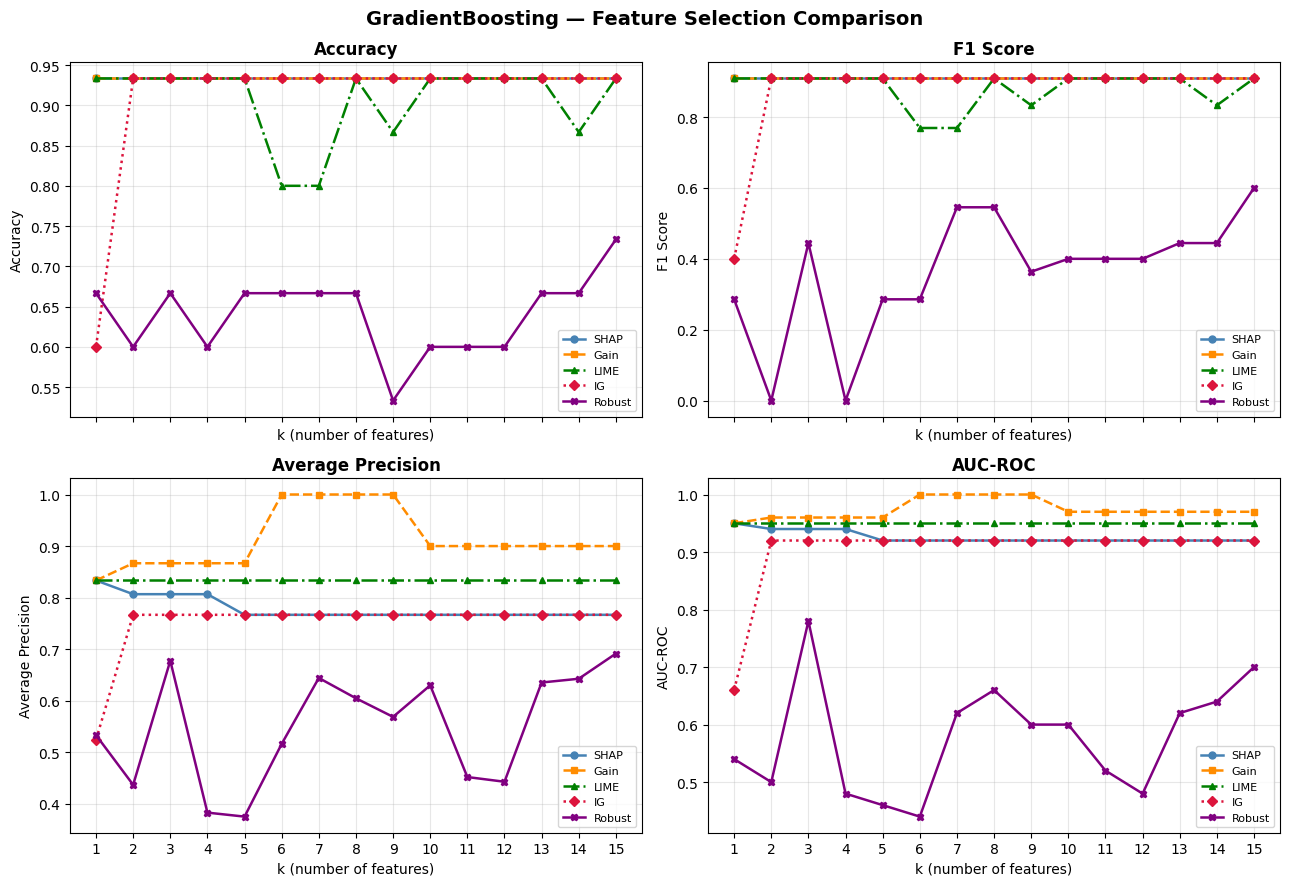

In [43]:
k_values = list(range(1, 16))

print('Evaluating GradientBoosting — SHAP...')
gradientboosting_res_shap = evaluate_topk(MODELS['GradientBoosting'], gradientboosting_shap, X_train, X_test, y_train, y_test, k_values)

print('Evaluating GradientBoosting — Gain...')
gradientboosting_res_gain = evaluate_topk(MODELS['GradientBoosting'], gradientboosting_gain, X_train, X_test, y_train, y_test, k_values) if gradientboosting_gain is not None else None

print('Evaluating GradientBoosting — LIME...')
gradientboosting_res_lime = evaluate_topk(MODELS['GradientBoosting'], gradientboosting_lime, X_train, X_test, y_train, y_test, k_values)

print('Evaluating GradientBoosting — IG...')
gradientboosting_res_ig = evaluate_topk(MODELS['GradientBoosting'], ig_ranking, X_train, X_test, y_train, y_test, k_values)

print('Evaluating GradientBoosting — Robust Bootstrap...')
gradientboosting_res_robust = evaluate_topk(MODELS['GradientBoosting'], gradientboosting_robust, X_train, X_test, y_train, y_test, k_values)

plot_comparison(
    'GradientBoosting',
    {'SHAP': gradientboosting_res_shap, 'Gain': gradientboosting_res_gain,
     'LIME': gradientboosting_res_lime, 'IG':   gradientboosting_res_ig, 'Robust': gradientboosting_res_robust},
    k_values,
)


---
## LogisticRegression

### LogisticRegression — SHAP

In [44]:
print('Computing SHAP ranking for LogisticRegression...')
logisticregression_shap = get_shap_ranking(MODELS['LogisticRegression'], X_train, y_train)
print('Top-10:')
logisticregression_shap.head(10)

Computing SHAP ranking for LogisticRegression...
Top-10:


,feature,importance
0,Y07604_at,1.252613
1,U46499_at,1.051777
2,X95735_at,1.029793
3,X69111_at,1.000250
4,M34344_at,0.950174
5,M84371_rna1_s_at,0.948599
6,U19713_s_at,0.946021
7,M23197_at,0.941362
8,M13690_s_at,0.940712
9,U15555_at,0.935232


### LogisticRegression — Gain

In [45]:
print('Computing Gain ranking for LogisticRegression...')
logisticregression_gain = get_gain_ranking(MODELS['LogisticRegression'], X_train, y_train)
if logisticregression_gain is not None:
    print('Top-10:')
    display(logisticregression_gain.head(10))
else:
    print('Gain not supported for LogisticRegression')


Computing Gain ranking for LogisticRegression...
Top-10:


,feature,importance
0,Y07604_at,0.027398
1,M31994_at,0.027309
2,M34344_at,0.026568
3,U59632_s_at,0.026409
4,X06948_at,0.024202
5,M20902_at,0.023270
6,X95735_at,0.022963
7,M19507_at,0.022523
8,M10612_at,0.022053
9,U46499_at,0.021664


### LogisticRegression — LIME

_Adjust `n_samples` and `num_features` to trade speed for accuracy._

In [46]:
print('Computing LIME ranking for LogisticRegression...')
logisticregression_lime = get_lime_ranking(
    MODELS['LogisticRegression'], X_train, y_train,
    n_samples=10,    # increase for better estimates
    num_features=50, # top features per explanation
)
print('Top-10:')
logisticregression_lime.head(10)


Computing LIME ranking for LogisticRegression...


Top-10:


,feature,importance
0,M34344_at,0.000957
1,M20902_at,0.000785
2,X95735_at,0.000645
3,M12759_at,0.000611
4,U15197_at,0.000608
5,X69111_at,0.000596
6,M31994_at,0.000578
7,X13973_at,0.000578
8,U91903_at,0.000549
9,M92287_at,0.000529


### LogisticRegression — Robust

In [ ]:
# first50 = logisticregression_shap['feature'].head(50).tolist()

In [47]:
lr_boot_unscreen = boot_multi_repeat_inference_keep_feature(
    X=X_train,
    y=y_train,
    inner_variance="permutation",
    task="binary",
    n_bootstrap=1000,  
    b_model=1, 
    zero_tol=0,
    model_wrapper=lr_wrapper,  
    n_jobs=6,        
    show_progress=True
)

Bootstrap repeats (feature-agg): 100%|██████████| 1000/1000 [02:31<00:00,  6.61it/s]


In [48]:
lr_feature_kde = estimate_feature_level_mixture_preagg(
    boot_results=lr_boot_unscreen,
    bandwidth=0.2,
    kernel="gaussian",
    zero_tol=1e-8
)

In [49]:
tmp = lr_feature_kde.copy()

tmp["0PM(%)"] = (tmp["pi_zero"] * 100).round(1).astype(str) + "%"
tmp["SNR"] = tmp["median"] / tmp["sd_estimated"]
tmp["stat"] = tmp["p_nonzero"]* tmp["nonzero_median"] * tmp["SNR"]
                                
top = tmp.nlargest(15, "stat").reset_index(drop=True)
top.index += 1
top.index.name = "Rank"
# top[["feature", "stat", "SNR", "nonzero_median", "sd_estimated", "0PM(%)"]].rename(columns={
#     "feature": "Group",
#     "stat": "importance",
#     "nonzero_median": "Median",
#     "sd_estimated": "Std",
# }).round(3)

logisticregression_robust = top[['feature', 'stat']].rename(columns={'stat': 'importance'})
logisticregression_robust.head(10)


,feature,importance
Rank,,
1,Y07604_at,1.270521
2,X95735_at,1.153374
3,M23197_at,1.091941
4,U46499_at,1.083065
5,M84371_rna1_s_at,1.074656
6,M27891_at,1.021290
7,U05259_rna1_at,0.976509
8,M55150_at,0.969352
9,M62762_at,0.957082


### LogisticRegression — Evaluation & Comparison

Evaluating LogisticRegression — SHAP...
Evaluating LogisticRegression — Gain...
Evaluating LogisticRegression — LIME...
Evaluating LogisticRegression — IG...
Evaluating LogisticRegression — Robust Bootstrap...


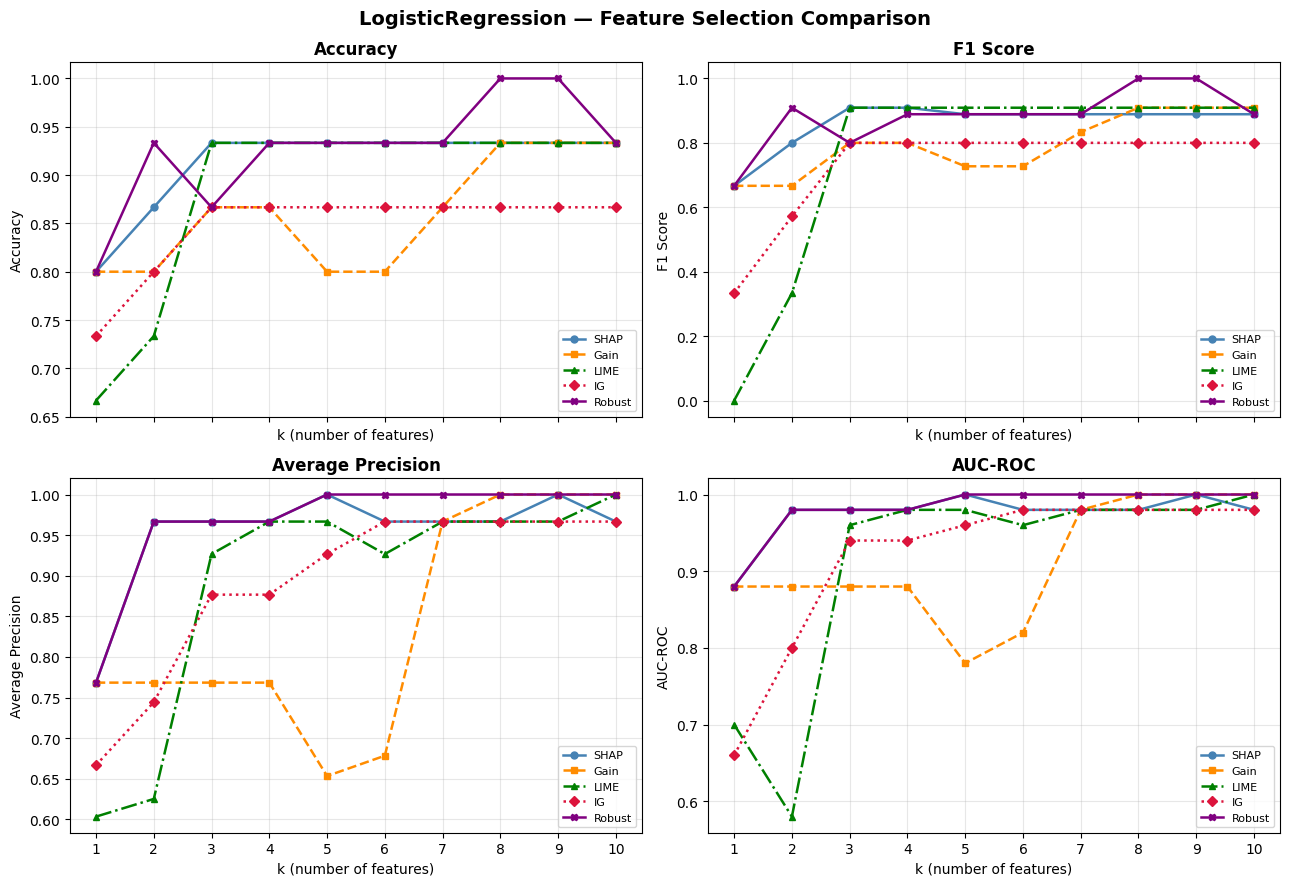

In [50]:
k_values = list(range(1, 11))

print('Evaluating LogisticRegression — SHAP...')
logisticregression_res_shap = evaluate_topk(MODELS['LogisticRegression'], logisticregression_shap, X_train, X_test, y_train, y_test, k_values)

print('Evaluating LogisticRegression — Gain...')
logisticregression_res_gain = evaluate_topk(MODELS['LogisticRegression'], logisticregression_gain, X_train, X_test, y_train, y_test, k_values) if logisticregression_gain is not None else None

print('Evaluating LogisticRegression — LIME...')
logisticregression_res_lime = evaluate_topk(MODELS['LogisticRegression'], logisticregression_lime, X_train, X_test, y_train, y_test, k_values)

print('Evaluating LogisticRegression — IG...')
logisticregression_res_ig = evaluate_topk(MODELS['LogisticRegression'], ig_ranking, X_train, X_test, y_train, y_test, k_values)

print('Evaluating LogisticRegression — Robust Bootstrap...')
logisticregression_res_robust = evaluate_topk(MODELS['LogisticRegression'], logisticregression_robust, X_train, X_test, y_train, y_test, k_values)

plot_comparison(
    'LogisticRegression',
    {'SHAP': logisticregression_res_shap, 'Gain': logisticregression_res_gain,
     'LIME': logisticregression_res_lime, 'IG':   logisticregression_res_ig, 'Robust': logisticregression_res_robust},
    k_values,
)
